In [1]:
import jax
import numpy as np
import flax.linen as nn

import matplotlib.pyplot as plt
import h5py as hf
from dataclasses import dataclass
import seaborn as sns
from mpl_toolkits.mplot3d import axes3d
from matplotlib.lines import Line2D


In [2]:
@dataclass
class Measurement:
    data: np.ndarray
    uncertainty: np.ndarray

In [16]:
def load_data(
    temperature: int, speed: int, radius: float, ensembles: int = 10
):
    """
    Load data from a specific experiment and average over ensembles.
    """
    root_path = f"{temperature}/{speed}/{radius}mum"
    distances = []
    
    for i in range(1, 11):
        with hf.File(f"{root_path}/{i}/training/trajectory.hdf5", "r") as db:
            data = db["colloids"]["Unwrapped_Positions"][:]
            distance_to_source = np.linalg.norm(data - np.array([500., 500., 0.]), axis=-1)
            distances.append(
                Measurement(
                    data=np.mean(distance_to_source, axis=1),
                    uncertainty=np.std(distance_to_source, axis=1)
                )
                
            )
    
    
    return distances

In [17]:
sizes = np.arange(0.025, 2.51, 0.075)
temperature=300
speeds=np.linspace(1, 5, 5, dtype=int)

# Rate of Success

We check if the last 500 points are les than 30 micro-meters from the source and if so, consider the model as a success.

In [18]:
results = {}

for speed in speeds:
    results[speed] = {}
    for size in sizes:
        data = load_data(temperature=temperature, speed=speed, radius=f"{size:0.3f}")

        results[speed][size] = 0

        for distances in data:
            if np.mean(distances.data[500:]) < 15:
                results[speed][size] += 1

        results[speed][size] /= 10
        

/Users/samueltovey/miniconda3/envs/zincware/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/samueltovey/miniconda3/envs/zincware/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [19]:
sizes = np.arange(0.025, 2.51, 0.075)
speeds=np.linspace(1, 5, 5, dtype=int)

data_points = np.zeros((len(speeds), len(sizes)))
his_points = []

for i, item in enumerate(speeds[::-1]):
    
    x = list(results[item].keys())
    y = list(results[item].values())
    
    for j, size in enumerate(x):
        data_points[i, j] = y[j]
        his_points.append([size, item, y[j]])
    
his_points = np.array(his_points)

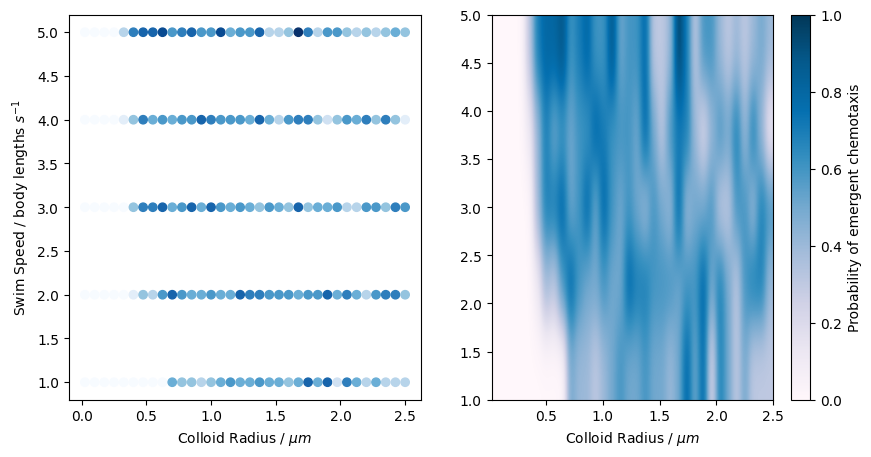

In [20]:
# quadric, gaussian, bessel, mitchell, lanczos
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Scatter plot
ax[0].scatter(his_points[:, 0], his_points[:, 1], c=his_points[:, 2], cmap="Blues")

# Image plot
img = ax[1].imshow(
    data_points, 
    extent=[0.025, 2.5, 1.0, 5.0], 
    aspect="auto", 
    vmin=0.,
    vmax=1.,
    interpolation="gaussian",
    cmap="PuBu"
)

ax[0].set_xlabel(r"Colloid Radius / $\mu m$")
ax[1].set_xlabel(r"Colloid Radius / $\mu m$")

ax[0].set_ylabel(r"Swim Speed / body lengths $s^{-1}$")
cbar = fig.colorbar(img)
cbar.set_label("Probability of emergent chemotaxis")
plt.savefig("probability-phase-diagram.pdf")
plt.show()

# Policy Efficiency

Here we plot the average distance for the last 500 steps as well as the rate at which the colloids reach the center for each size.

## Final distance

In [21]:
results = {}


for speed in speeds:
    results[speed] = {}
    for size in sizes:
        data = load_data(temperature=temperature, speed=speed, radius=f"{size:0.3f}")

        distance_array = []

        for distances in data:
            if np.mean(distances.data[500:]) < 15:
                distance_array.append(np.mean(distances.data[500:]))

        results[speed][size] = Measurement(
            data=np.mean(distance_array),
            uncertainty=np.std(distance_array)
        )
    

/Users/samueltovey/miniconda3/envs/zincware/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/samueltovey/miniconda3/envs/zincware/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/Users/samueltovey/miniconda3/envs/zincware/lib/python3.10/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/samueltovey/miniconda3/envs/zincware/lib/python3.10/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/Users/samueltovey/miniconda3/envs/zincware/lib/python3.10/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.

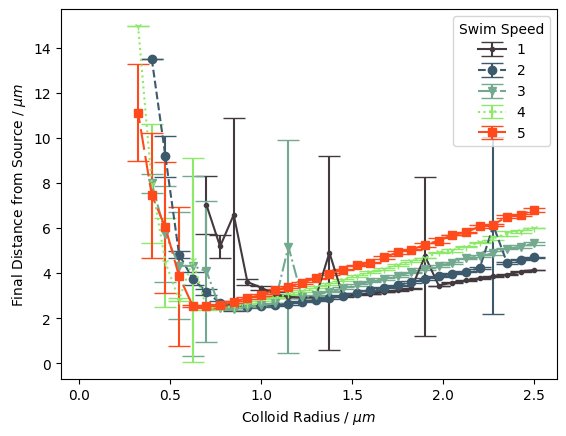

In [22]:
linestyles = [
    '-', '--', '-.', ':', (5, (10, 3))
]
markers = [
    ".", "o", "v", "1", "s"
]
colours = [
    "#433A3F",
    "#3D5A6C",
    "#72A98F", 
    "#8DE969", 
    "#FF4A1C"
]

for i, item in enumerate(results):
    x_values = results[item].keys()
    y_values = results[item].values()
    
    plt.errorbar(
        x=x_values, 
        y=[item.data for item in y_values], 
        yerr=[item.uncertainty for item in y_values],
        marker=markers[i],
        capsize=8,
        ls=linestyles[i],
        label=item,
        c=colours[i]
    )

plt.xlabel(r"Colloid Radius / $\mu m$")
plt.ylabel(r"Final Distance from Source / $\mu m$")
plt.legend(title="Swim Speed")
plt.savefig("convergence-distance.pdf")
plt.show()


## Convergence Rate 

In [23]:
results = {}

for speed in speeds:
    results[speed] = {}
    for size in sizes:
        data = load_data(temperature=temperature, speed=speed, radius=f"{size:0.3f}")

        distance_array = []

        for distances in data:
            if np.mean(distances.data[500:]) < 15 and max(distances.data) < 100:
                distance_array.append(distances.data)

        results[speed][size] = Measurement(
            data=np.mean(distance_array, axis=0),
            uncertainty=np.std(distance_array, axis=0)
        )

/Users/samueltovey/miniconda3/envs/zincware/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/samueltovey/miniconda3/envs/zincware/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/Users/samueltovey/miniconda3/envs/zincware/lib/python3.10/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/samueltovey/miniconda3/envs/zincware/lib/python3.10/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/Users/samueltovey/miniconda3/envs/zincware/lib/python3.10/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.

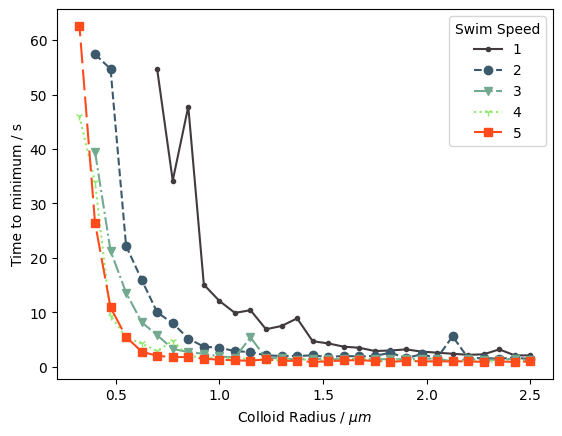

In [24]:
linestyles = [
    '-', '--', '-.', ':', (5, (10, 3))
]
markers = [
    ".", "o", "v", "1", "s"
]
colours = [
    "#433A3F",
    "#3D5A6C",
    "#72A98F", 
    "#8DE969", 
    "#FF4A1C"
]

for i, item in enumerate(results):
    convergence_rate = []
    sizes = []
    errors = []
    for size in results[item]:
        try:
            index = np.where(results[item][size].data <= 10.0)[0][0]
            convergence_rate.append(index)
            sizes.append(size)
        except:
            continue

    plt.plot(
        sizes, 
        np.array(convergence_rate) * 0.1, 
        marker=markers[i],
        ls=linestyles[i],
        c=colours[i],
        label=item)

plt.xlabel(r"Colloid Radius / $\mu m$")
plt.ylabel(r"Time to minimum / s")
plt.legend(title="Swim Speed")
plt.savefig("convergence-speed.pdf")
plt.show()

# Policy Evaluation

Here we use the policy evaluation tool to compare learned approaches.

In [5]:
results = {}

class ActorNet(nn.Module):
    """A simple dense model."""

    @nn.compact
    def __call__(self, x):
        x = nn.Dense(features=128)(x)
        x = nn.relu(x)
        x = nn.Dense(features=128)(x)
        x = nn.relu(x)
        x = nn.Dense(features=4)(x)
        return x
    
model = ActorNet()
x = np.linspace(-1.7, 1.7, 100)

for speed in speeds:
    results[speed] = {}
    for size in sizes:
        data = load_data(temperature=temperature, speed=speed, radius=f"{size:0.3f}")
        actions = []
        
        for i, item in enumerate(data):
            if np.mean(item.data[500:]) < 15 and max(item.data) < 100:
                parameters = np.load(
                    f"{temperature}/{speed}/{size:0.3f}mum/{i + 1}/Models/ActorModel_0.pkl",
                    allow_pickle=True
                )
                actions.append(
                        jax.nn.softmax(model.apply({"params": parameters[0]}, x.reshape(-1, 1))),
                )
            
        results[speed][f'{size:.3f}'] = Measurement(
            data=np.mean(actions, axis=0),
            uncertainty=np.std(actions, axis=0)
        )

/Users/samueltovey/miniconda3/envs/zincware/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/samueltovey/miniconda3/envs/zincware/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/Users/samueltovey/miniconda3/envs/zincware/lib/python3.10/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/samueltovey/miniconda3/envs/zincware/lib/python3.10/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/Users/samueltovey/miniconda3/envs/zincware/lib/python3.10/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.

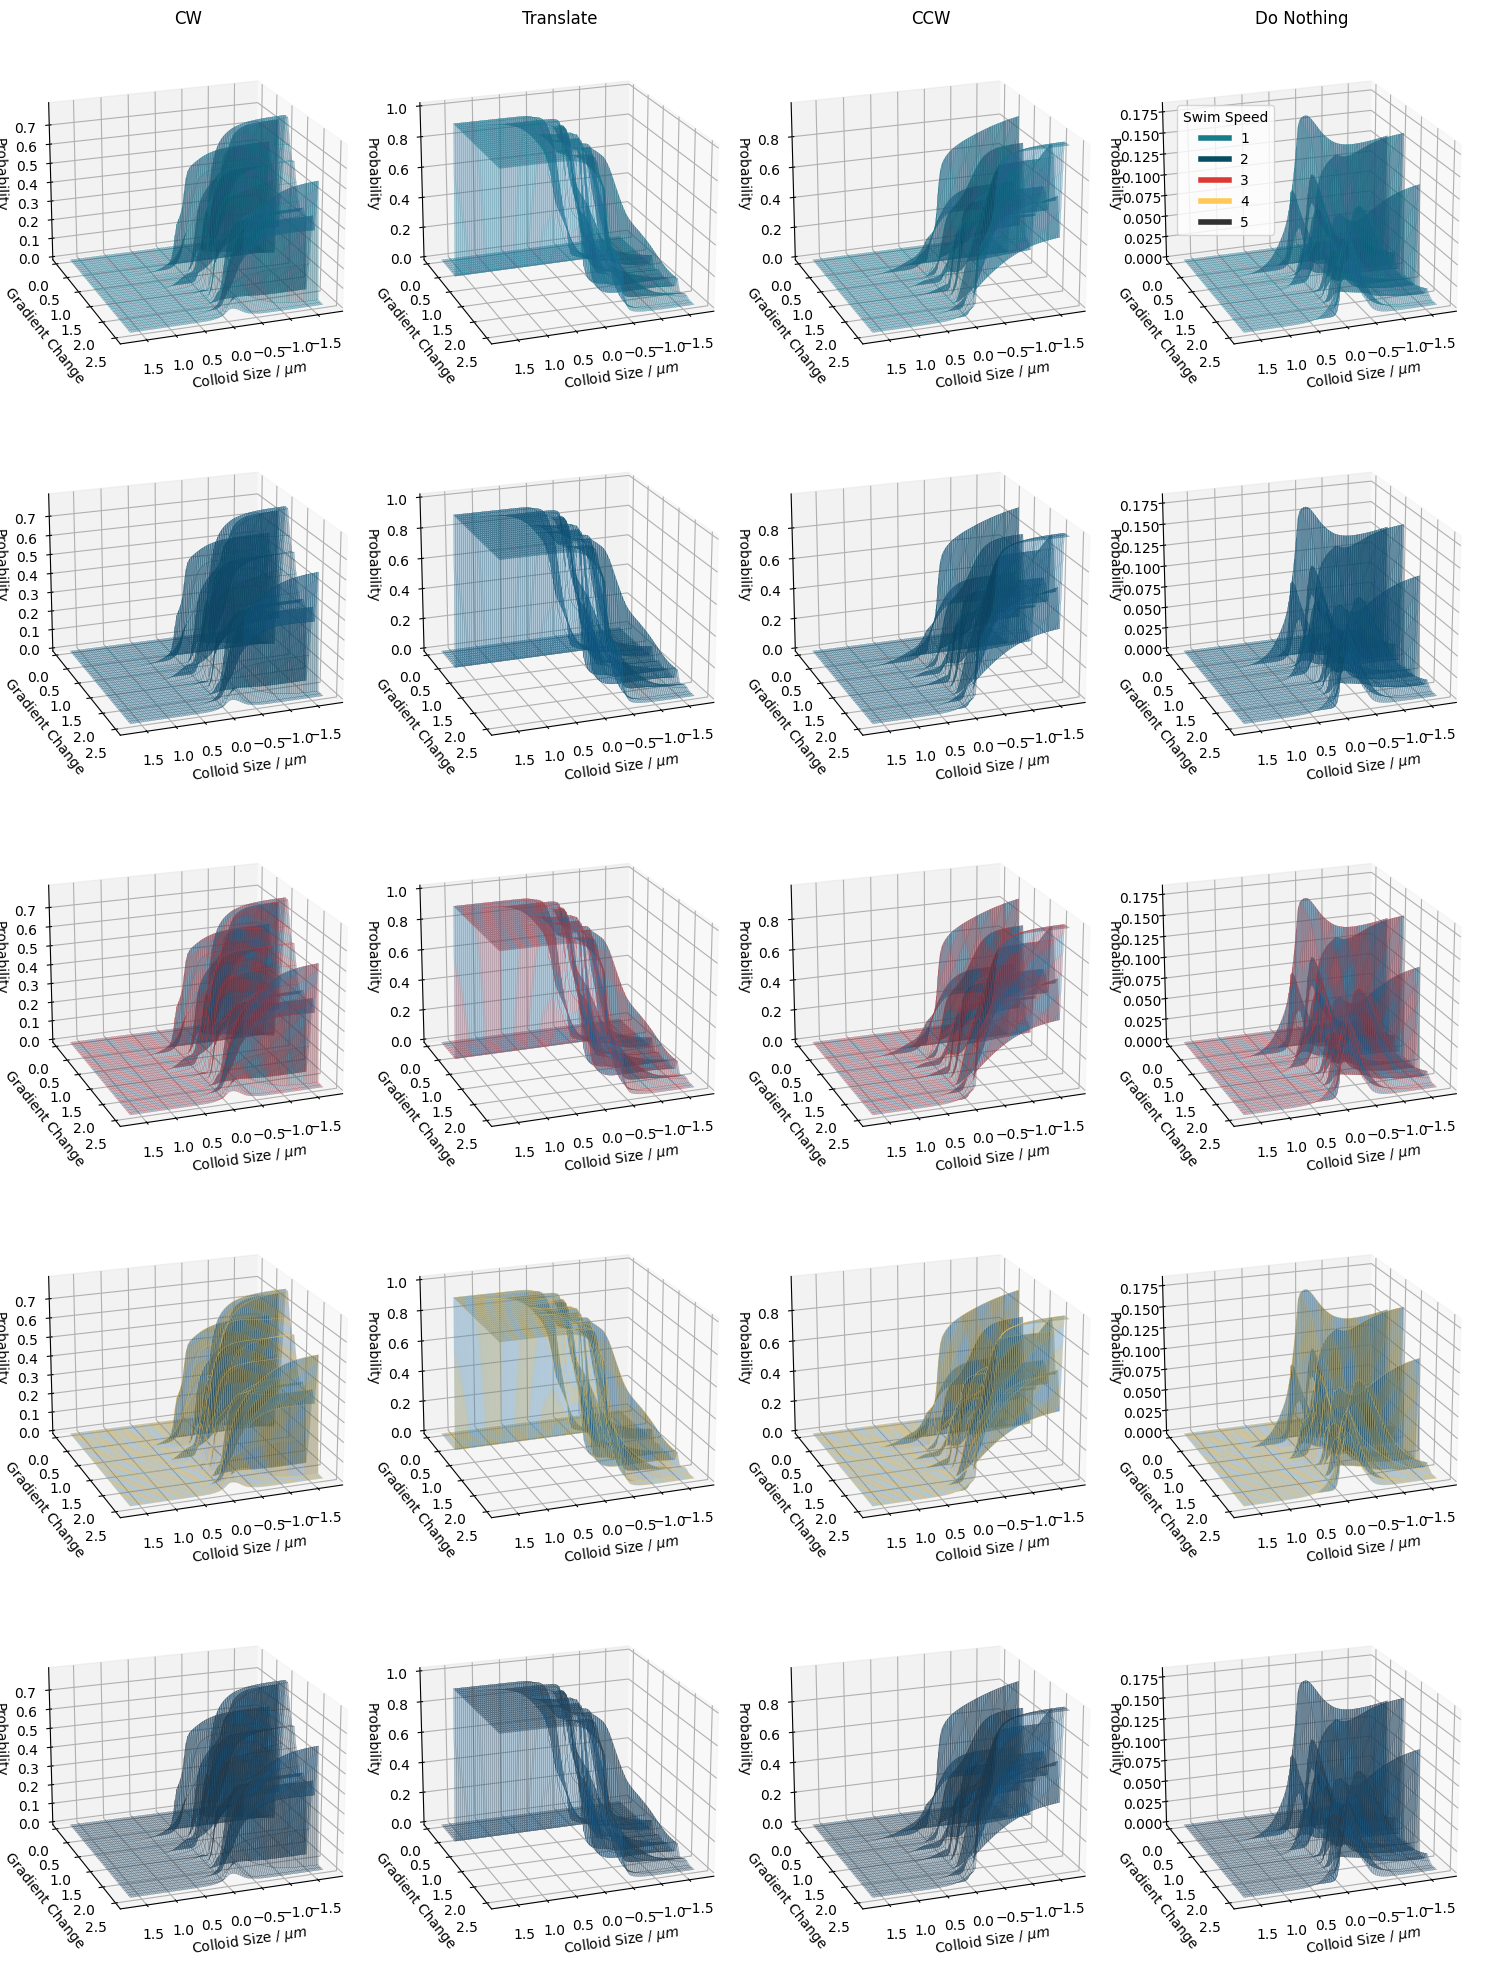

In [15]:
speeds=np.linspace(1, 5, 5, dtype=int)
colours = [
    "#177E89",
    "#084C61",
    "#DB3A34", 
    "#FFC857", 
    "#323031"
]

fig, ax = plt.subplots(len(speeds), 4, figsize=(15, 20), subplot_kw={"projection": '3d'})


for j, speed in enumerate(speeds):
    X, Y = np.meshgrid(x, np.array(list(results[speed].keys()), dtype=float))
    Z_cw = np.zeros_like(Y)
    Z_tr = np.zeros_like(Y)
    Z_ccw = np.zeros_like(Y)
    Z_dn = np.zeros_like(Y)

    for i, item in enumerate(results[speed]):    
        try:
            Z_cw[i, :] = results[1][item].data[:, 0]
        except:
            Z_cw[i, :] = np.zeros_like(Y[i])

        try:
            Z_tr[i, :] = results[1][item].data[:, 1]
        except:
            Z_tr[i, :] = np.zeros_like(Y[i])

        try:
            Z_ccw[i, :] = results[1][item].data[:, 2]
        except:
            Z_ccw[i, :] = np.zeros_like(Y[i])

        try:
            Z_dn[i, :] = results[1][item].data[:, 3]
        except:
            Z_dn[i, :] = np.zeros_like(Y[i])


    ax[j, 0].plot_surface(
        X, Y, Z_cw, 
        edgecolor=colours[j], 
        lw=0.1,
        rstride=1, 
        cstride=1, 
        alpha=0.3,
        label="ahgh"
    )

    ax[j, 0].view_init(elev=20., azim=70.)

    ax[j, 1].plot_surface(
        X, Y, Z_tr, 
        edgecolor=colours[j], 
        lw=0.1,
        rstride=1, 
        cstride=1, 
        alpha=0.3,
    )

    ax[j, 1].view_init(elev=20., azim=70.)

    ax[j, 2].plot_surface(
        X, Y, Z_ccw, 
        edgecolor=colours[j], 
        lw=0.1,
        rstride=1, 
        cstride=1, 
        alpha=0.3,
    )

    ax[j, 2].view_init(elev=20., azim=70.)

    ax[j, 3].plot_surface(
        X, Y, Z_dn, 
        edgecolor=colours[j], 
        lw=0.1,
        rstride=1, 
        cstride=1, 
        alpha=0.3,
    )

    ax[j, 3].view_init(elev=20., azim=70.)
    
    if j == 0:
        ax[j, 0].set_title("CW")
        ax[j, 1].set_title("Translate")
        ax[j, 2].set_title("CCW")
        ax[j, 3].set_title("Do Nothing")

        
    ax[j, 0].set_xlabel(r"Colloid Size / $\mu m$")
    ax[j, 0].set_ylabel("Gradient Change")
    ax[j, 0].set_zlabel("Probability")

    ax[j, 1].set_xlabel(r"Colloid Size / $\mu m$")
    ax[j, 1].set_ylabel("Gradient Change")
    ax[j, 1].set_zlabel("Probability")

    ax[j, 2].set_xlabel(r"Colloid Size / $\mu m$")
    ax[j, 2].set_ylabel("Gradient Change")
    ax[j, 2].set_zlabel("Probability")

    ax[j, 3].set_xlabel(r"Colloid Size / $\mu m$")
    ax[j, 3].set_ylabel("Gradient Change")
    ax[j, 3].set_zlabel("Probability")

plt.tight_layout()


custom_lines = [
    Line2D([0], [0], color=colours[0], lw=4),
    Line2D([0], [0], color=colours[1], lw=4),
    Line2D([0], [0], color=colours[2], lw=4),
    Line2D([0], [0], color=colours[3], lw=4),
    Line2D([0], [0], color=colours[4], lw=4)
]

fig.legend(custom_lines, [1, 2, 3, 4, 5], title="Swim Speed", loc=(0.79, 0.88))


plt.savefig("policy.png", bbox_inches='tight')
plt.show()